# Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity
from xgboost import XGBClassifier
import joblib, os, warnings
warnings.filterwarnings('ignore')

# Load Cleaned Data

In [3]:
df = pd.read_csv('../data/processed_data.csv')
print('shape:', df.shape)
df.head(3)

shape: (52930, 18)


,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating,ContinentId,RegionId,CountryId,CityId,CityName,Country,Region,Continent,AttractionTypeId,Attraction,AttractionType
0,3,70456,2022,10,2,640,5,5,21,163,4341.0,Guildford,United Kingdom,Western Europe,Europe,63,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas
1,8,7567,2022,10,4,640,5,2,8,48,464.0,Ontario,Canada,Northern America,America,63,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas
2,9,79069,2022,10,3,640,5,2,9,54,774.0,Brazil,Brazil,South America,America,63,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas


# Encode VisitMode for Classification

In [4]:
le = LabelEncoder()
df['VisitMode_enc'] = le.fit_transform(df['VisitMode'])

print('VisitMode encoding:')
for i, c in enumerate(le.classes_):
    print(f'  {i} -> {c}')

VisitMode encoding:
  0 -> 1
  1 -> 2
  2 -> 3
  3 -> 4
  4 -> 5


# Define Features and Targests

In [5]:
all_possible = ['ContinentId', 'RegionId', 'CountryId', 'CityId',
                'VisitYear', 'VisitMonth', 'AttractionTypeId', 'AttractionId']
features = [f for f in all_possible if f in df.columns]

X        = df[features]
y_rating = df['Rating']
y_mode   = df['VisitMode_enc']

print('features used:', features)
print('X shape      :', X.shape)
print('classes      :', y_mode.nunique())

features used: ['ContinentId', 'RegionId', 'CountryId', 'CityId', 'VisitYear', 'VisitMonth', 'AttractionTypeId', 'AttractionId']
X shape      : (52930, 8)
classes      : 5


# Train Test Split(with NaN fix)

In [6]:
X = X.fillna(X.median())

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X, y_rating, test_size=0.2, random_state=42
)
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X, y_mode, test_size=0.2, random_state=42, stratify=y_mode
)

print('null values in X after fix:', X.isnull().sum().sum())
print('regression     train:', Xr_train.shape, '| test:', Xr_test.shape)
print('classification train:', Xc_train.shape, '| test:', Xc_test.shape)

null values in X after fix: 0
regression     train: (42344, 8) | test: (10586, 8)
classification train: (42344, 8) | test: (10586, 8)


# Train and Compare Regression Models

In [7]:
reg_models = {
    'Linear Regression' : LinearRegression(),
    'Random Forest'     : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=100, random_state=42)
}

reg_results = {}

for name, model in reg_models.items():
    model.fit(Xr_train, yr_train)
    p = model.predict(Xr_test)
    reg_results[name] = {
        'R2' : round(r2_score(yr_test, p), 4),
        'MSE': round(mean_squared_error(yr_test, p), 4),
        'MAE': round(mean_absolute_error(yr_test, p), 4)
    }
    print(f"{name:22} => R2: {reg_results[name]['R2']}  MSE: {reg_results[name]['MSE']}  MAE: {reg_results[name]['MAE']}")

best_reg_name  = max(reg_results, key=lambda x: reg_results[x]['R2'])
best_reg_model = reg_models[best_reg_name]
print(f'\nbest regression model: {best_reg_name}')

Linear Regression      => R2: 0.033  MSE: 0.9107  MAE: 0.7543
Random Forest          => R2: 0.008  MSE: 0.9343  MAE: 0.7398
Gradient Boosting      => R2: 0.1136  MSE: 0.8348  MAE: 0.7167

best regression model: Gradient Boosting


# Regression Comparison Chart

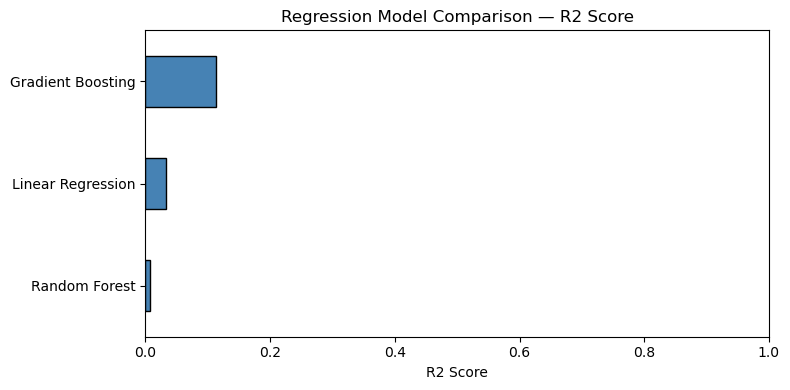

In [8]:
r2_scores = {k: v['R2'] for k, v in reg_results.items()}
pd.Series(r2_scores).sort_values().plot(kind='barh', color='steelblue', edgecolor='black', figsize=(8, 4))
plt.title('Regression Model Comparison — R2 Score')
plt.xlabel('R2 Score')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

# Train and Compare Classification Models

In [9]:
log_reg = LogisticRegression(max_iter=500, random_state=42)
rf_cls  = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
xgb_cls = XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss')

cls_models = {
    'Logistic Regression': log_reg,
    'Random Forest'      : rf_cls,
    'XGBoost'            : xgb_cls
}

cls_results = {}

for name, model in cls_models.items():
    model.fit(Xc_train, yc_train)
    acc = accuracy_score(yc_test, model.predict(Xc_test))
    cls_results[name] = round(acc, 4)
    print(f"{name:22} => Accuracy: {cls_results[name]}")

# automatically picks whichever model gave best accuracy
best_cls_name  = max(cls_results, key=cls_results.get)
best_cls_model = cls_models[best_cls_name]

print(f'\nbest model: {best_cls_name} with accuracy {cls_results[best_cls_name]}')

Logistic Regression    => Accuracy: 0.4087
Random Forest          => Accuracy: 0.4684
XGBoost                => Accuracy: 0.4974

best model: XGBoost with accuracy 0.4974


# Detailed Classification Report

In [10]:
preds        = best_cls_model.predict(Xc_test)
target_names = [str(x) for x in le.classes_]

print(f'Classification Report — {best_cls_name}\n')
print(classification_report(yc_test, preds, target_names=target_names))

Classification Report — XGBoost

              precision    recall  f1-score   support

           1       0.53      0.06      0.11       125
           2       0.50      0.79      0.61      4324
           3       0.53      0.45      0.48      3043
           4       0.40      0.19      0.26      2189
           5       0.47      0.07      0.12       905

    accuracy                           0.50     10586
   macro avg       0.49      0.31      0.32     10586
weighted avg       0.49      0.50      0.45     10586



# Classification Comparison Chart

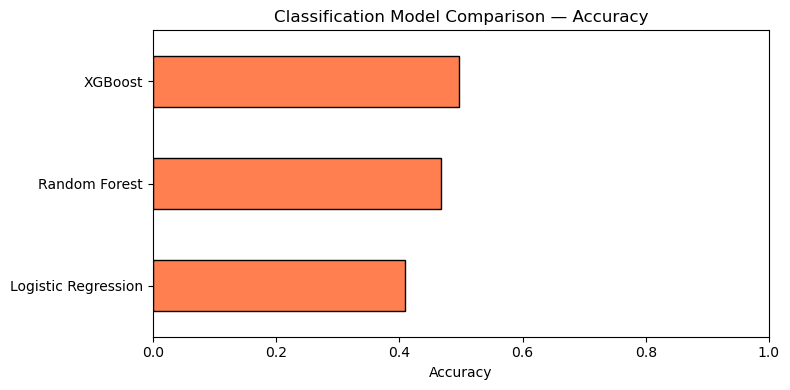

In [11]:
pd.Series(cls_results).sort_values().plot(
    kind='barh', color='coral', edgecolor='black', figsize=(8, 4)
)
plt.title('Classification Model Comparison — Accuracy')
plt.xlabel('Accuracy')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

# Confusion Matrix

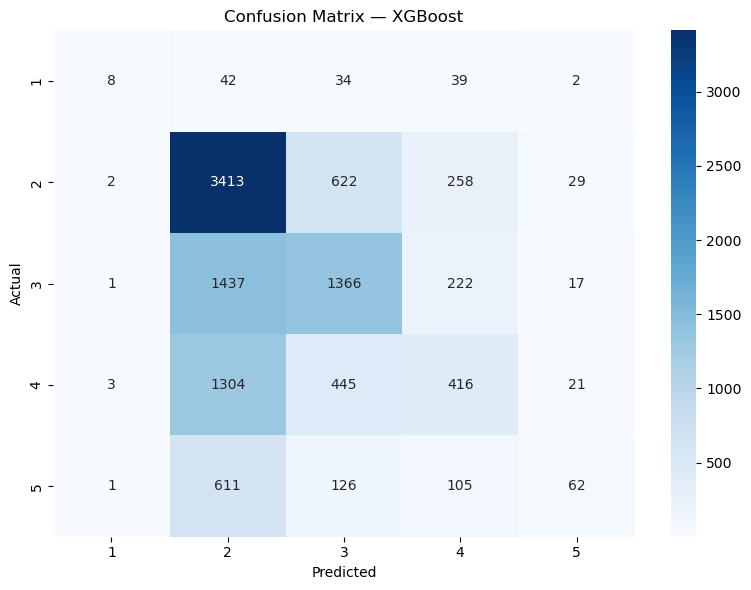

In [12]:
target_names = [str(x) for x in le.classes_]

cm = confusion_matrix(yc_test, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)
plt.title(f'Confusion Matrix — {best_cls_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Build Recommendation System

In [13]:
user_item = df.pivot_table(index='UserId', columns='AttractionId', values='Rating')

sim_df = pd.DataFrame(
    cosine_similarity(user_item.fillna(0)),
    index=user_item.index,
    columns=user_item.index
)

print('user-item matrix  :', user_item.shape)
print('similarity matrix :', sim_df.shape)

user-item matrix  : (33530, 30)
similarity matrix : (33530, 33530)


# Test Recommendation Function

In [14]:
def get_recs(user_id, n=10):
    if user_id not in sim_df.index:
        print('user not found')
        return None

    similar  = sim_df[user_id].sort_values(ascending=False)[1:11].index.tolist()
    seen     = user_item.loc[user_id].dropna().index.tolist()
    avg      = user_item.loc[similar].mean(axis=0)
    unseen   = avg.drop(index=seen, errors='ignore').sort_values(ascending=False).head(n)

    name_map = df[['AttractionId', 'Attraction']].drop_duplicates().set_index('AttractionId')['Attraction']
    type_map = df[['AttractionId', 'AttractionType']].drop_duplicates().set_index('AttractionId')['AttractionType']

    return pd.DataFrame({
        'Attraction'      : unseen.index.map(name_map),
        'Type'            : unseen.index.map(type_map),
        'Predicted Rating': unseen.values.round(2)
    }).reset_index(drop=True)

sample_user = user_item.index[0]
print(f'recommendations for user {sample_user}:\n')
get_recs(sample_user)

recommendations for user 14:



,Attraction,Type,Predicted Rating
0,Kuta Beach - Bali,Beaches,NaN
1,Nusa Dua Beach,Beaches,NaN
2,Sanur Beach,Beaches,NaN
3,Seminyak Beach,Beaches,NaN
4,Tanah Lot Temple,Religious Sites,NaN
5,Tegenungan Waterfall,Waterfalls,NaN
6,Uluwatu Temple,Religious Sites,NaN
7,Waterbom Bali,Water Parks,NaN
8,Balekambang Beach,Beaches,NaN
9,Bromo Tengger Semeru National Park,National Parks,NaN


# Save All Models

In [15]:
os.makedirs('../models', exist_ok=True)

joblib.dump(best_reg_model, '../models/reg_model.pkl')
joblib.dump(best_cls_model, '../models/cls_model.pkl')
joblib.dump(le,             '../models/label_encoder.pkl')
joblib.dump(user_item,      '../models/user_item.pkl')
joblib.dump(features,       '../models/features.pkl')

print('all saved')
print(f'regression model    : {best_reg_name}')
print(f'classification model: {best_cls_name}')

all saved
regression model    : Gradient Boosting
classification model: XGBoost
